In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import joblib
import os

# load the data
df = pd.read_csv('../data/sensor_data.csv')

print("Data loaded:", df.shape)
print(df.head(3))

Data loaded: (250, 13)
   session  belt_speed  vfd_frequency  expected_speed  speed_deviation  \
0        1       0.783             50            0.80           -0.017   
1        2       0.530             35            0.56           -0.030   
2        3       0.631             40            0.64           -0.009   

   temperature  current  items_count  maintenance_done_today  \
0         54.5     1.74           26                       0   
1         60.0     2.40           47                       0   
2         48.6     2.23           27                       0   

   days_since_maintenance  interventions_30d   rul  alerts_today  
0                       1                  0  90.0             0  
1                       2                  0  88.0             1  
2                       3                  0  86.0             0  


In [2]:
# ── MODEL 1 : ISOLATION FOREST (Anomaly Detection) ────────

features_anomaly = ['belt_speed', 'speed_deviation', 'temperature', 'current', 'items_count']
X_anomaly = df[features_anomaly]

anomaly_model = IsolationForest(
    n_estimators=100,
    contamination=0.16,  # 40 wear days out of 250 = 16%
    random_state=42
)

anomaly_model.fit(X_anomaly)

scores = anomaly_model.decision_function(X_anomaly)
anomaly_scores = (100 - ((scores - scores.min()) / (scores.max() - scores.min()) * 100)).round(1)

df['anomaly_score'] = anomaly_scores

print("Anomaly model trained ✓")
print("\nFirst 5 days (should be LOW score):")
print(df[['session', 'belt_speed', 'speed_deviation', 'temperature', 'anomaly_score']].head())
print("\nLast 5 sessions (should be HIGH score):")
print(df[['session', 'belt_speed', 'speed_deviation', 'temperature', 'anomaly_score']].tail())
 
joblib.dump(anomaly_model, '../models/anomaly.pkl')
print("\nanomaly.pkl saved ✓")

Anomaly model trained ✓

First 5 days (should be LOW score):
   session  belt_speed  speed_deviation  temperature  anomaly_score
0        1       0.783           -0.017         54.5           16.5
1        2       0.530           -0.030         60.0           37.6
2        3       0.631           -0.009         48.6           17.3
3        4       0.817            0.017         52.6            3.3
4        5       0.804            0.004         55.0            6.6

Last 5 sessions (should be HIGH score):
     session  belt_speed  speed_deviation  temperature  anomaly_score
245      246       0.275           -0.285         74.7           73.2
246      247       0.475           -0.325         74.1           60.5
247      248       0.250           -0.310         77.6          100.0
248      249       0.226           -0.334         82.0           94.7
249      250       0.299           -0.341         82.0           93.9

anomaly.pkl saved ✓


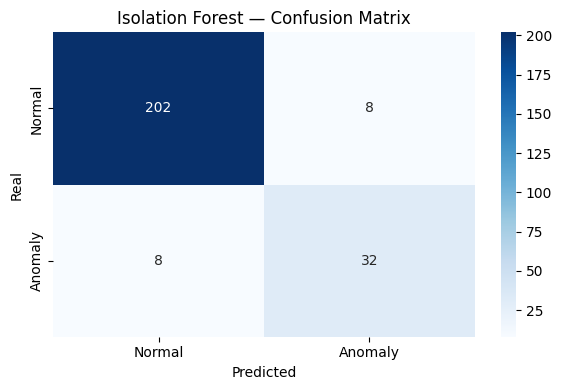


               precision    recall  f1-score   support

      Normal       0.80      0.80      0.80        40
     Anomaly       0.96      0.96      0.96       210

    accuracy                           0.94       250
   macro avg       0.88      0.88      0.88       250
weighted avg       0.94      0.94      0.94       250



In [3]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# real labels: 210 normal + 40 anomaly
real_labels = [1] * 210 + [-1] * 40

# what isolation forest predicted
predicted_labels = anomaly_model.predict(X_anomaly)

# confusion matrix
cm = confusion_matrix(real_labels, predicted_labels, labels=[1, -1])

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])
plt.title('Isolation Forest — Confusion Matrix')
plt.ylabel('Real')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print("\n", classification_report(real_labels, predicted_labels,
      target_names=['Normal', 'Anomaly']))

In [4]:
# ── MODEL 2 : XGBOOST REGRESSOR (Remaining Useful Life) ──

features_rul = ['belt_speed', 'speed_deviation', 'temperature', 
                'current', 'days_since_maintenance', 'interventions_30d']
X_rul = df[features_rul]
y_rul = df['rul']

X_train, X_test, y_train, y_test = train_test_split(
    X_rul, y_rul, test_size=0.2, random_state=42
)

rul_model = XGBRegressor(n_estimators=100, random_state=42)
rul_model.fit(X_train, y_train)

predictions = rul_model.predict(X_test).round(1)

print("RUL model trained ✓")
print("\nSample predictions vs real values:")
for i in range(5):
    print(f"  Predicted: {predictions[i]} days  |  Real: {y_test.values[i]} days")

from sklearn.metrics import mean_absolute_error, r2_score
mae = mean_absolute_error(y_test, predictions)
r2  = r2_score(y_test, predictions)
print(f"\nAverage error : {mae:.1f} days off")
print(f"R2 score      : {r2:.2f}  (1.0 = perfect)")

joblib.dump(rul_model, '../models/rul.pkl')
print("\nrul.pkl saved ✓")

RUL model trained ✓

Sample predictions vs real values:
  Predicted: 74.0 days  |  Real: 74.0 days
  Predicted: 77.30000305175781 days  |  Real: 78.0 days
  Predicted: 74.5999984741211 days  |  Real: 74.0 days
  Predicted: 88.0999984741211 days  |  Real: 88.0 days
  Predicted: 74.0 days  |  Real: 74.0 days

Average error : 0.9 days off
R2 score      : 0.98  (1.0 = perfect)

rul.pkl saved ✓


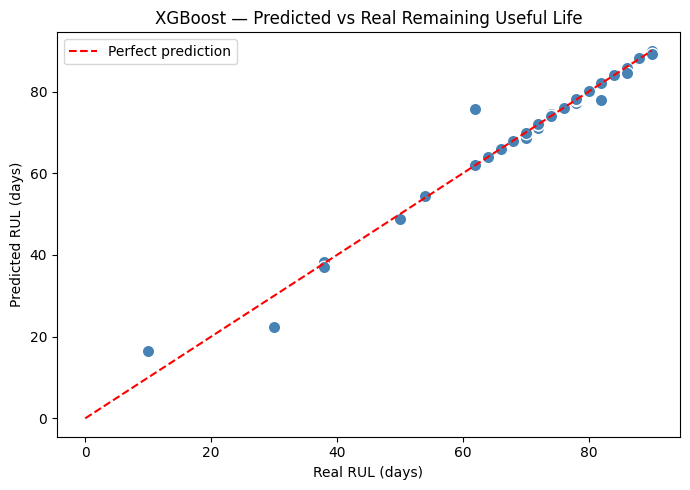

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.scatter(y_test, predictions, color='steelblue', edgecolors='white', s=80)
plt.plot([0, 90], [0, 90], color='red', linestyle='--', label='Perfect prediction')
plt.xlabel('Real RUL (days)')
plt.ylabel('Predicted RUL (days)')
plt.title('XGBoost — Predicted vs Real Remaining Useful Life')
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
# ── MODEL 3 : RANDOM FOREST (Failure Probability 24h) ────

def label_alerts(count):
    if count <= 2:   return 'LOW'
    elif count <= 7: return 'MODERATE'
    else:            return 'HIGH'

df['alert_label'] = df['alerts_today'].apply(label_alerts)

features_rf = ['belt_speed', 'speed_deviation', 'temperature',
               'current', 'items_count', 'days_since_maintenance',
               'interventions_30d']

X_rf = df[features_rf]
y_rf = df['alert_label']

X_train, X_test, y_train, y_test = train_test_split(
    X_rf, y_rf, test_size=0.2, random_state=42
)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

predictions_rf = rf_model.predict(X_test)

print("Random Forest trained ✓")
print("\nSample predictions vs real:")
for i in range(5):
    print(f"  Predicted: {predictions_rf[i]}  |  Real: {y_test.values[i]}")

joblib.dump(rf_model, '../models/alert.pkl')
print("\nalert.pkl saved ✓")

Random Forest trained ✓

Sample predictions vs real:
  Predicted: LOW  |  Real: LOW
  Predicted: LOW  |  Real: LOW
  Predicted: LOW  |  Real: LOW
  Predicted: LOW  |  Real: LOW
  Predicted: LOW  |  Real: LOW

alert.pkl saved ✓


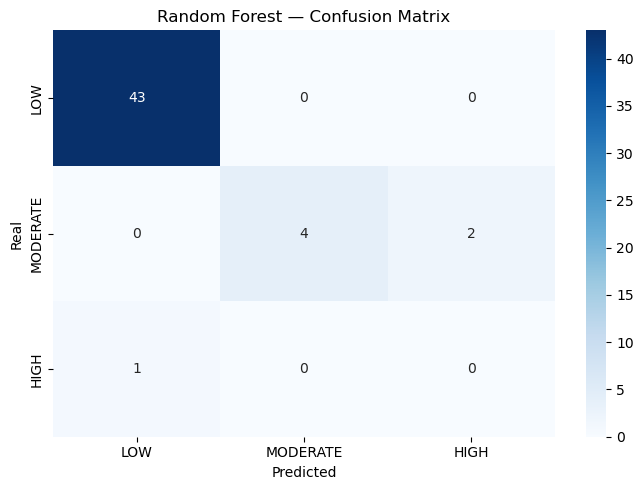


               precision    recall  f1-score   support

         LOW       0.00      0.00      0.00         1
    MODERATE       0.98      1.00      0.99        43
        HIGH       1.00      0.67      0.80         6

    accuracy                           0.94        50
   macro avg       0.66      0.56      0.60        50
weighted avg       0.96      0.94      0.95        50



In [26]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

labels = ['LOW', 'MODERATE', 'HIGH']

cm = confusion_matrix(y_test, predictions_rf, labels=labels)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)
plt.title('Random Forest — Confusion Matrix')
plt.ylabel('Real')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print("\n", classification_report(y_test, predictions_rf, target_names=labels))